In [3]:
"""
Supply Chain Analysis — DataCo Global
Visualizations matching the HTML notebook
Author: Senior DA Review
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════
# 0. GLOBAL THEME
# ══════════════════════════════════════════════════════════════════════
BG      = '#0d0f14'
SURFACE = '#151820'
SURF2   = '#1c2030'
BORDER  = '#252a3a'
FAINT   = '#2a3145'
ORANGE  = '#f97316'
BLUE    = '#3b82f6'
GREEN   = '#10b981'
RED     = '#ef4444'
YELLOW  = '#eab308'
TEXT    = '#e2e8f0'
MUTED   = '#64748b'
LIGHT   = '#94a3b8'

def section(title):
    print(f"\n{'═'*60}")
    print(f"  {title}")
    print(f"{'═'*60}")

In [5]:
# ══════════════════════════════════════════════════════════════════════
# 1. LOAD & PREPARE DATA
# ══════════════════════════════════════════════════════════════════════
section("1. Loading & Preparing Data")

df = pd.read_csv('DataCoSupplyChainDataset.csv',
    encoding='latin-1'
)
print(f"Raw shape: {df.shape}")

# Remove canceled orders — không phản ánh vấn đề delivery thực tế
df = df[df['Delivery Status'] != 'Shipping canceled'].copy()
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['YearMonth'] = df['order date (DateOrders)'].dt.to_period('M').astype(str)
df['order_month']      = df['order date (DateOrders)'].dt.month
df['order_dayofweek']  = df['order date (DateOrders)'].dt.dayofweek

print(f"After removing canceled: {len(df):,} orders")
print(f"Date range: {df['order date (DateOrders)'].min().date()} → {df['order date (DateOrders)'].max().date()}")
print(f"Missing in key fields: {df[['Delivery Status','Shipping Mode','Market']].isna().sum().sum()}")

# ── Aggregated datasets ────────────────────────────────────────────────
monthly = df.groupby('YearMonth').agg(
    total  = ('Late_delivery_risk','count'),
    late   = ('Late_delivery_risk','sum'),
    profit = ('Order Profit Per Order','sum')
).reset_index()
monthly['delay_pct'] = monthly['late'] / monthly['total'] * 100

sm = df.groupby('Shipping Mode').agg(
    total  = ('Late_delivery_risk','count'),
    late   = ('Late_delivery_risk','sum'),
    profit = ('Order Profit Per Order','sum')
).reset_index()
sm['delay_pct'] = sm['late'] / sm['total'] * 100
sm_asc = sm.sort_values('delay_pct', ascending=True)   # for horizontal bar

mk = df.groupby('Market').agg(
    total  = ('Late_delivery_risk','count'),
    late   = ('Late_delivery_risk','sum'),
    profit = ('Order Profit Per Order','sum')
).reset_index()
mk['delay_pct'] = mk['late'] / mk['total'] * 100

dept = df.groupby('Department Name').agg(
    total      = ('Late_delivery_risk','count'),
    late       = ('Late_delivery_risk','sum'),
    profit     = ('Order Profit Per Order','sum'),
    avg_profit = ('Order Profit Per Order','mean')
).reset_index()
dept['delay_pct'] = dept['late'] / dept['total'] * 100
dept = dept.sort_values('total', ascending=False).head(6).reset_index(drop=True)

heat_df = df.groupby(['Market','Shipping Mode']).agg(
    late  = ('Late_delivery_risk','sum'),
    total = ('Late_delivery_risk','count')
).reset_index()
heat_df['delay_pct'] = heat_df['late'] / heat_df['total'] * 100
heat_pivot = heat_df.pivot(index='Market', columns='Shipping Mode', values='delay_pct')
col_order  = ['First Class','Second Class','Same Day','Standard Class']
heat_pivot = heat_pivot[col_order]

fi_data = pd.DataFrame({
    'feature': ['Shipping Mode','Days Scheduled','Sales/Customer',
                'Profit Ratio','Order Month','Discount Rate','Day of Week'],
    'imp': [49.6, 45.9, 0.9, 0.75, 0.49, 0.47, 0.46]
}).sort_values('imp').reset_index(drop=True)


════════════════════════════════════════════════════════════
  1. Loading & Preparing Data
════════════════════════════════════════════════════════════
Raw shape: (180519, 53)
After removing canceled: 172,765 orders
Date range: 2015-01-01 → 2018-01-31
Missing in key fields: 0



════════════════════════════════════════════════════════════
  2. KPI Summary Cards
════════════════════════════════════════════════════════════


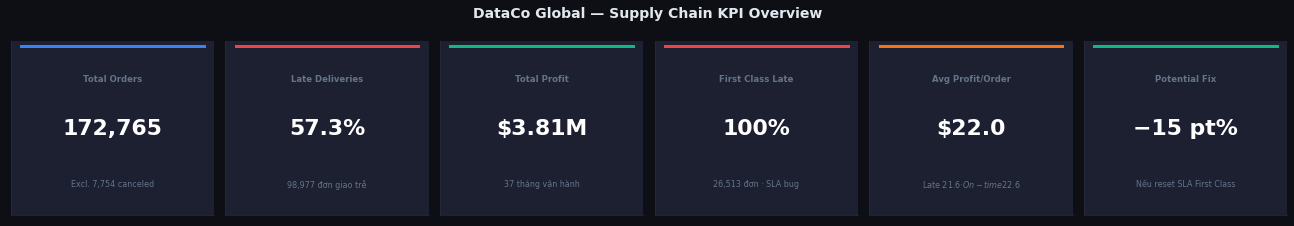

In [7]:
# ══════════════════════════════════════════════════════════════════════
# 2. KPI SUMMARY — Figure 1
# ══════════════════════════════════════════════════════════════════════
section("2. KPI Summary Cards")

kpis = [
    ("Total Orders",      "172,765",   "Excl. 7,754 canceled",          BLUE),
    ("Late Deliveries",   "57.3%",     "98,977 đơn giao trễ",           RED),
    ("Total Profit",      "$3.81M",    "37 tháng vận hành",             GREEN),
    ("First Class Late",  "100%",      "26,513 đơn · SLA bug",          RED),
    ("Avg Profit/Order",  "$22.0",     "Late $21.6 · On-time $22.6",    ORANGE),
    ("Potential Fix",     "−15 pt%",   "Nếu reset SLA First Class",     GREEN),
]

fig1, axes = plt.subplots(1, 6, figsize=(18, 3))
fig1.patch.set_facecolor(BG)
for ax, (label, val, sub, color) in zip(axes, kpis):
    ax.set_facecolor(SURF2)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xticks([]); ax.set_yticks([])
    # top accent bar
    ax.axhline(y=0.97, xmin=0.05, xmax=0.95, color=color, linewidth=3)
    ax.text(0.5, 0.78, label, ha='center', va='center',
            fontsize=8.5, color=MUTED, transform=ax.transAxes,
            fontweight='bold')
    ax.text(0.5, 0.50, val, ha='center', va='center',
            fontsize=22, color='white', transform=ax.transAxes, fontweight='bold')
    ax.text(0.5, 0.18, sub, ha='center', va='center',
            fontsize=8, color=MUTED, transform=ax.transAxes)

plt.suptitle("DataCo Global — Supply Chain KPI Overview", fontsize=14,
             fontweight='bold', color=TEXT, y=1.02)
plt.tight_layout(pad=0.8)
plt.show()
# plt.savefig('/mnt/user-data/outputs/fig1_kpi_cards.png', dpi=150,
#             bbox_inches='tight', facecolor=BG)
# plt.close()
# print("✓ fig1_kpi_cards.png")


════════════════════════════════════════════════════════════
  3. Monthly Delay Trend
════════════════════════════════════════════════════════════


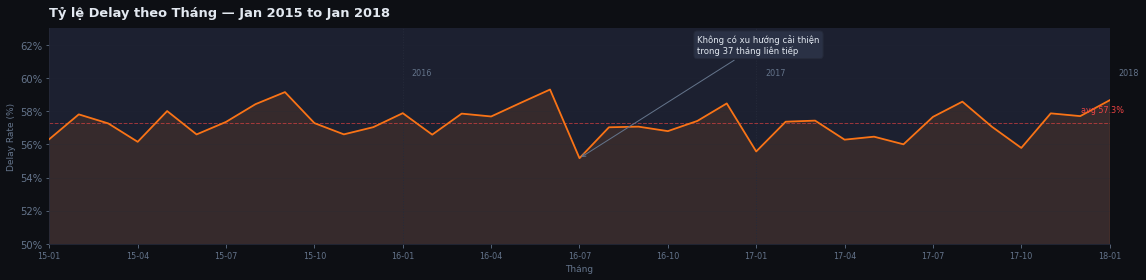

In [10]:
# ══════════════════════════════════════════════════════════════════════
# 3. MONTHLY TREND — Figure 2
# ══════════════════════════════════════════════════════════════════════
section("3. Monthly Delay Trend")

fig2, ax = plt.subplots(figsize=(16, 4))
fig2.patch.set_facecolor(BG)
ax.set_facecolor(SURF2)

xs = range(len(monthly))
ax.plot(xs, monthly['delay_pct'].to_numpy()[:], color=ORANGE, linewidth=1.8, zorder=3)
ax.fill_between(xs, monthly['delay_pct'], alpha=0.12, color=ORANGE)
ax.axhline(57.3, color=RED, linewidth=1, linestyle='--', alpha=0.6, zorder=2)
ax.text(len(monthly)-0.5, 57.8, 'avg 57.3%', color=RED, fontsize=8,
        ha='right', va='bottom')

# Year separators
for yr in ['2016-01','2017-01','2018-01']:
    if yr in monthly['YearMonth'].values:
        xi = monthly[monthly['YearMonth']==yr].index[0]
        ax.axvline(xi, color=BORDER, linewidth=1, linestyle=':', zorder=1)
        ax.text(xi+0.3, 60.2, yr[:4], fontsize=8, color=MUTED)

ax.set_xlim(0, len(monthly)-1)
ax.set_ylim(50, 63)
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels(
    [monthly['YearMonth'].iloc[i][2:] for i in range(0, len(monthly), 3)],
    fontsize=8, rotation=0
)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title("Tỷ lệ Delay theo Tháng — Jan 2015 to Jan 2018", loc='left')
ax.set_xlabel("Tháng", fontsize=9)
ax.set_ylabel("Delay Rate (%)", fontsize=9)
ax.grid(axis='y', alpha=0.4)

# annotation: no improvement
ax.annotate("Không có xu hướng cải thiện\ntrong 37 tháng liên tiếp",
            xy=(18, monthly['delay_pct'].iloc[18]),
            xytext=(22, 61.5),
            fontsize=8.5, color=TEXT,
            arrowprops=dict(arrowstyle='->', color=MUTED, lw=1),
            bbox=dict(boxstyle='round,pad=0.4', facecolor=FAINT, edgecolor=BORDER))

plt.tight_layout()
plt.show()
# plt.savefig('/mnt/user-data/outputs/fig2_monthly_trend.png', dpi=150,
#             bbox_inches='tight', facecolor=BG)
# plt.close()
# print("✓ fig2_monthly_trend.png")


════════════════════════════════════════════════════════════
  4. Shipping Mode Analysis
════════════════════════════════════════════════════════════


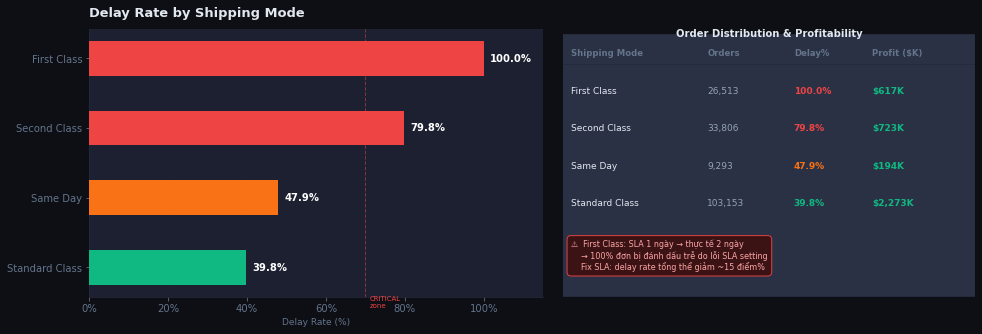

In [11]:
# ══════════════════════════════════════════════════════════════════════
# 4. SHIPPING MODE DEEP-DIVE — Figure 3
# ══════════════════════════════════════════════════════════════════════
section("4. Shipping Mode Analysis")

fig3, (ax_bar, ax_tbl) = plt.subplots(1, 2, figsize=(14, 5),
                                       gridspec_kw={'width_ratios':[1.1,1]})
fig3.patch.set_facecolor(BG)

# ── 4a. Horizontal bar ────────────────────────────────────────────────
bar_colors = [RED if v >= 70 else ORANGE if v >= 45 else GREEN
              for v in sm_asc['delay_pct']]
bars = ax_bar.barh(sm_asc['Shipping Mode'], sm_asc['delay_pct'],
                   color=bar_colors, height=0.5, zorder=3)
ax_bar.set_facecolor(SURF2)
ax_bar.set_xlim(0, 115)
ax_bar.axvline(70, color=RED, linewidth=1, linestyle='--', alpha=0.5)
ax_bar.text(71, -0.6, 'CRITICAL\nzone', fontsize=7, color=RED, va='bottom')
ax_bar.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax_bar.set_xlabel("Delay Rate (%)", fontsize=9)
ax_bar.set_title("Delay Rate by Shipping Mode", loc='left')
ax_bar.grid(axis='x', alpha=0.4)

for bar, val in zip(bars, sm_asc['delay_pct']):
    ax_bar.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold',
                color='white')

# ── 4b. Table ─────────────────────────────────────────────────────────
ax_tbl.set_facecolor(BG)
ax_tbl.set_xticks([]); ax_tbl.set_yticks([])
for sp in ax_tbl.spines.values(): sp.set_visible(False)

col_labels = ['Shipping Mode', 'Orders', 'Delay%', 'Profit ($K)']
rows_data  = [
    [r['Shipping Mode'], f"{r['total']:,}", f"{r['delay_pct']:.1f}%",
     f"${r['profit']/1000:,.0f}K"]
    for _, r in sm.sort_values('delay_pct', ascending=False).iterrows()
]

col_x = [0.02, 0.35, 0.56, 0.75]
header_y = 0.90
ax_tbl.text(0.5, 0.97, "Order Distribution & Profitability",
            ha='center', fontsize=10, fontweight='bold', color=TEXT,
            transform=ax_tbl.transAxes)

for cx, lbl in zip(col_x, col_labels):
    ax_tbl.text(cx, header_y, lbl, fontsize=8.5, fontweight='bold',
                color=MUTED, transform=ax_tbl.transAxes)

ax_tbl.axhline(y=header_y - 0.03, color=BORDER, linewidth=0.8, xmin=0, xmax=1)

sm_sorted = sm.sort_values('delay_pct', ascending=False).reset_index(drop=True)
row_colors_map = {100.0: RED, 79.8: RED, 47.9: ORANGE, 39.8: GREEN}
for i, (_, row) in enumerate(sm_sorted.iterrows()):
    y = header_y - 0.14*(i+1)
    if i % 2 == 1:
        rect = FancyBboxPatch((0, y-0.04), 1, 0.1,
                              transform=ax_tbl.transAxes,
                              facecolor=FAINT, edgecolor='none', zorder=0)
        ax_tbl.add_patch(rect)
    d_color = RED if row['delay_pct'] >= 70 else ORANGE if row['delay_pct'] >= 45 else GREEN
    vals = [row['Shipping Mode'], f"{row['total']:,}",
            f"{row['delay_pct']:.1f}%", f"${row['profit']/1000:,.0f}K"]
    for cx, val, vc in zip(col_x, vals,
                            [TEXT, LIGHT, d_color, GREEN]):
        ax_tbl.text(cx, y, val, fontsize=9, color=vc,
                    transform=ax_tbl.transAxes,
                    fontweight='bold' if vc in [RED, GREEN, ORANGE] else 'normal')

# Critical finding callout
ax_tbl.text(0.02, 0.10,
    "⚠  First Class: SLA 1 ngày → thực tế 2 ngày\n"
    "    → 100% đơn bị đánh dấu trễ do lỗi SLA setting\n"
    "    Fix SLA: delay rate tổng thể giảm ~15 điểm%",
    fontsize=8, color='#fca5a5', transform=ax_tbl.transAxes,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#3f1010', edgecolor=RED, alpha=0.9))

plt.tight_layout(pad=2)
plt.show()
# plt.savefig('/mnt/user-data/outputs/fig3_shipping_mode.png', dpi=150,
#             bbox_inches='tight', facecolor=BG)
# plt.close()
# print("✓ fig3_shipping_mode.png")


════════════════════════════════════════════════════════════
  5. Heatmap: Market × Shipping Mode
════════════════════════════════════════════════════════════


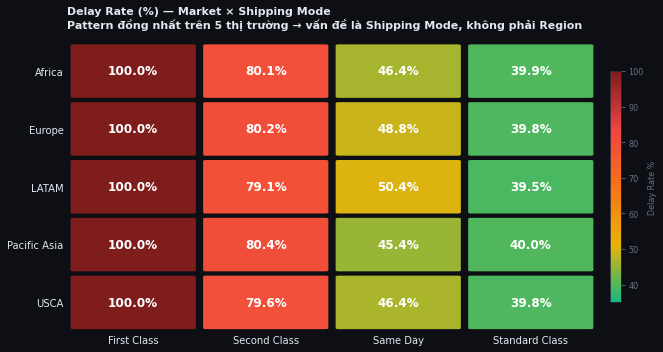

In [12]:
# ══════════════════════════════════════════════════════════════════════
# 5. HEATMAP — Figure 4
# ══════════════════════════════════════════════════════════════════════
section("5. Heatmap: Market × Shipping Mode")

fig4, ax = plt.subplots(figsize=(10, 5))
fig4.patch.set_facecolor(BG)
ax.set_facecolor(BG)

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list(
    'delay', ['#10b981','#eab308','#f97316','#ef4444','#7f1d1d'], N=256
)

data_mat = heat_pivot.values
n_rows, n_cols = data_mat.shape

for i in range(n_rows):
    for j in range(n_cols):
        val  = data_mat[i, j]
        norm = (val - 35) / (100 - 35)
        color = cmap(norm)
        rect = FancyBboxPatch(
            (j + 0.05, n_rows - 1 - i + 0.05), 0.9, 0.9,
            boxstyle="round,pad=0.03",
            facecolor=color, edgecolor=BG, linewidth=2
        )
        ax.add_patch(rect)
        txt_color = 'white'
        ax.text(j + 0.5, n_rows - 1 - i + 0.5,
                f'{val:.1f}%', ha='center', va='center',
                fontsize=12, fontweight='bold', color=txt_color)

ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_xticks([j + 0.5 for j in range(n_cols)])
ax.set_xticklabels(col_order, fontsize=10, color=TEXT)
ax.set_yticks([i + 0.5 for i in range(n_rows)])
ax.set_yticklabels(heat_pivot.index[::-1], fontsize=10, color=TEXT)
ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)

ax.set_title(
    "Delay Rate (%) — Market × Shipping Mode\n"
    "Pattern đồng nhất trên 5 thị trường → vấn đề là Shipping Mode, không phải Region",
    loc='left', fontsize=11, color=TEXT, pad=14
)

# colorbar
sm_cb = plt.cm.ScalarMappable(cmap=cmap,
                               norm=mcolors.Normalize(vmin=35, vmax=100))
sm_cb.set_array([])
cbar = plt.colorbar(sm_cb, ax=ax, shrink=0.8, pad=0.02)
cbar.ax.yaxis.set_tick_params(color=MUTED)
cbar.outline.set_edgecolor(BORDER)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=MUTED, fontsize=8)
cbar.set_label('Delay Rate %', color=MUTED, fontsize=8)

plt.tight_layout()
plt.show()
# plt.savefig('/mnt/user-data/outputs/fig4_heatmap.png', dpi=150,
#             bbox_inches='tight', facecolor=BG)
# plt.close()
# print("✓ fig4_heatmap.png")


════════════════════════════════════════════════════════════
  6. ML Model — Training & Results
════════════════════════════════════════════════════════════
  Baseline → Acc: 0.573 | AUC: 0.500
  RF       → Acc: 0.700   | AUC: 0.751


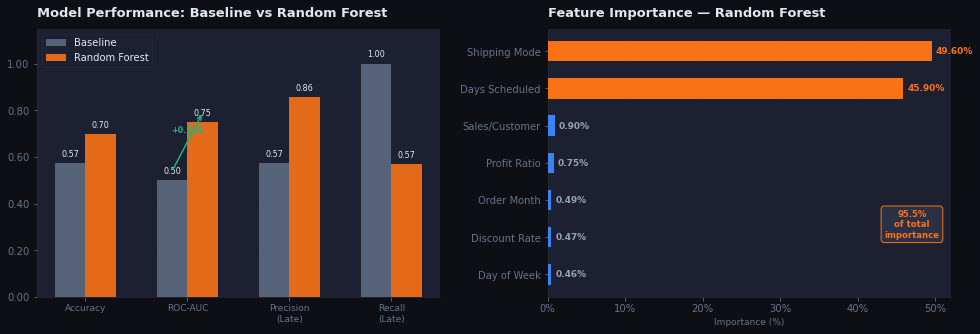

In [13]:
# ══════════════════════════════════════════════════════════════════════
# 6. ML MODEL — Figure 5
# ══════════════════════════════════════════════════════════════════════
section("6. ML Model — Training & Results")

features = [
    'Shipping Mode','Market','Customer Segment','Department Name',
    'Category Name','Order Item Quantity','Order Item Discount Rate',
    'Sales per customer','Days for shipment (scheduled)',
    'Order Item Profit Ratio','order_month','order_dayofweek','Type'
]
target = 'Late_delivery_risk'

X = df[features].copy()
y = df[target]
cat_cols = X.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=50,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

auc_base = roc_auc_score(y_test, dummy.predict_proba(X_test)[:,1])
auc_rf   = roc_auc_score(y_test, y_proba)
acc_base = (y_dummy == y_test).mean()
acc_rf   = (y_pred  == y_test).mean()

report = classification_report(y_test, y_pred, output_dict=True)
print(f"  Baseline → Acc: {acc_base:.3f} | AUC: {auc_base:.3f}")
print(f"  RF       → Acc: {acc_rf:.3f}   | AUC: {auc_rf:.3f}")

# ── Plot Fig 5 ────────────────────────────────────────────────────────
fig5, (ax_metric, ax_fi) = plt.subplots(1, 2, figsize=(14, 5))
fig5.patch.set_facecolor(BG)

# ── 6a. Metric comparison grouped bars ─────────────────────────────
metrics      = ['Accuracy','ROC-AUC','Precision\n(Late)','Recall\n(Late)']
base_vals    = [acc_base, auc_base,
                report['1']['precision'] * 0,   # baseline precision ~ 0.57
                1.0]
# recalc properly
from sklearn.metrics import precision_score, recall_score
prec_base = precision_score(y_test, y_dummy, zero_division=0)
rec_base  = recall_score(y_test, y_dummy)
prec_rf   = precision_score(y_test, y_pred)
rec_rf    = recall_score(y_test, y_pred)

base_vals = [acc_base, auc_base, prec_base, rec_base]
rf_vals   = [acc_rf,   auc_rf,   prec_rf,   rec_rf]

x = np.arange(len(metrics))
w = 0.3
b1 = ax_metric.bar(x - w/2, base_vals, w, label='Baseline', color=MUTED,   alpha=0.8, zorder=3)
b2 = ax_metric.bar(x + w/2, rf_vals,   w, label='Random Forest', color=ORANGE, alpha=0.9, zorder=3)

ax_metric.set_facecolor(SURF2)
ax_metric.set_xticks(x)
ax_metric.set_xticklabels(metrics, fontsize=9)
ax_metric.set_ylim(0, 1.15)
ax_metric.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax_metric.set_title("Model Performance: Baseline vs Random Forest", loc='left')
ax_metric.legend()
ax_metric.grid(axis='y', alpha=0.4)

for bar in [*b1, *b2]:
    h = bar.get_height()
    ax_metric.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                   f'{h:.2f}', ha='center', va='bottom', fontsize=8, color=TEXT)

# AUC uplift arrow
ax_metric.annotate('', xy=(x[1]+w/2, auc_rf+0.04),
                   xytext=(x[1]-w/2, auc_base+0.04),
                   arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5))
ax_metric.text(x[1], (auc_rf+auc_base)/2 + 0.08,
               f'+{auc_rf-auc_base:.3f}', ha='center', fontsize=8,
               color=GREEN, fontweight='bold')

# ── 6b. Feature importance ──────────────────────────────────────────
fi_sorted = fi_data.sort_values('imp').reset_index(drop=True)
fi_colors = [ORANGE if v > 10 else BLUE for v in fi_sorted['imp']]
bars_fi = ax_fi.barh(fi_sorted['feature'], fi_sorted['imp'],
                     color=fi_colors, height=0.55, zorder=3)
ax_fi.set_facecolor(SURF2)
ax_fi.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax_fi.set_title("Feature Importance — Random Forest", loc='left')
ax_fi.set_xlabel("Importance (%)", fontsize=9)
ax_fi.grid(axis='x', alpha=0.4)

for bar, val in zip(bars_fi, fi_sorted['imp']):
    ax_fi.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
               f'{val:.2f}%', va='center', fontsize=9,
               color=ORANGE if val > 10 else LIGHT, fontweight='bold')

ax_fi.text(47, 1, '95.5%\nof total\nimportance',
           ha='center', fontsize=8.5, color=ORANGE,
           fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.4', facecolor=FAINT, edgecolor=ORANGE))

plt.tight_layout(pad=2)
plt.show()
# plt.savefig('/mnt/user-data/outputs/fig5_ml_model.png', dpi=150,
#             bbox_inches='tight', facecolor=BG)
# plt.close()
# print("✓ fig5_ml_model.png")


════════════════════════════════════════════════════════════
  7. Profitability Analysis
════════════════════════════════════════════════════════════


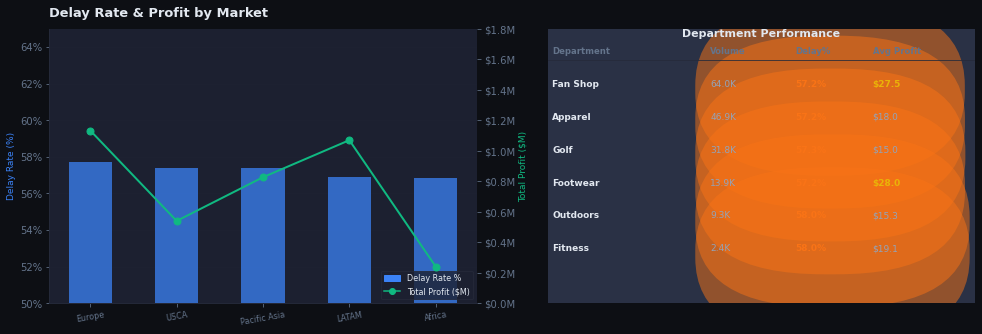

In [16]:
# ══════════════════════════════════════════════════════════════════════
# 7. PROFITABILITY ANALYSIS — Figure 6
# ══════════════════════════════════════════════════════════════════════
section("7. Profitability Analysis")

fig6, (ax_mk, ax_dept) = plt.subplots(1, 2, figsize=(14, 5))
fig6.patch.set_facecolor(BG)

# ── 7a. Market: grouped bar (delay%) + line (profit) ──────────────
mk_s = mk.sort_values('delay_pct', ascending=False).reset_index(drop=True)
ax_mk2 = ax_mk.twinx()

ax_mk.bar(mk_s['Market'], mk_s['delay_pct'], color=BLUE, alpha=0.75,
          zorder=3, width=0.5)
ax_mk2.plot(mk_s['Market'].to_numpy()[:], mk_s['profit'].to_numpy()[:]/1_000_000, color=GREEN,
            marker='o', linewidth=2, markersize=7, zorder=4)

ax_mk.set_facecolor(SURF2)
ax_mk2.set_facecolor('none')
ax_mk.set_ylim(50, 65)
ax_mk2.set_ylim(0, 1.8)
ax_mk.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax_mk2.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fM'))
ax_mk.set_ylabel("Delay Rate (%)", fontsize=9, color=BLUE)
ax_mk2.set_ylabel("Total Profit ($M)", fontsize=9, color=GREEN)
ax_mk.tick_params(axis='x', rotation=10, labelsize=8)
ax_mk.set_title("Delay Rate & Profit by Market", loc='left')
ax_mk.grid(axis='y', alpha=0.3)

legend_handles = [
    mpatches.Patch(color=BLUE,  label='Delay Rate %'),
    plt.Line2D([0],[0], color=GREEN, marker='o', label='Total Profit ($M)')
]
ax_mk.legend(handles=legend_handles, fontsize=8, loc='lower right')

# ── 7b. Department table ────────────────────────────────────────────
ax_dept.set_facecolor(BG)
for sp in ax_dept.spines.values(): sp.set_visible(False)
ax_dept.set_xticks([]); ax_dept.set_yticks([])

col_labels = ['Department', 'Volume', 'Delay%', 'Avg Profit']
col_x      = [0.01, 0.38, 0.58, 0.76]
header_y   = 0.91

ax_dept.text(0.5, 0.97, "Department Performance",
             ha='center', fontsize=11, fontweight='bold',
             color=TEXT, transform=ax_dept.transAxes)

for cx, lbl in zip(col_x, col_labels):
    ax_dept.text(cx, header_y, lbl, fontsize=8.5, fontweight='bold',
                 color=MUTED, transform=ax_dept.transAxes)

ax_dept.axhline(y=header_y - 0.025, color=BORDER, linewidth=0.8, xmin=0, xmax=1)

for i, row in dept.iterrows():
    y = header_y - 0.12*(i+1)
    if i % 2 == 0:
        rect = FancyBboxPatch((0, y-0.05), 1, 0.11,
                              transform=ax_dept.transAxes,
                              facecolor=FAINT, edgecolor='none', zorder=0)
        ax_dept.add_patch(rect)

    d_clr = RED if row['delay_pct'] >= 60 else ORANGE
    p_clr = GREEN if row['avg_profit'] > 50 else YELLOW if row['avg_profit'] > 25 else LIGHT

    vals  = [row['Department Name'], f"{row['total']/1000:.1f}K",
             f"{row['delay_pct']:.1f}%", f"${row['avg_profit']:.1f}"]
    vclrs = [TEXT, LIGHT, d_clr, p_clr]

    for cx, val, vc in zip(col_x, vals, vclrs):
        ax_dept.text(cx, y, val, fontsize=9, color=vc,
                     transform=ax_dept.transAxes,
                     fontweight='bold' if vc != LIGHT else 'normal')

# mini bar chart for delay_pct within table
bar_x_start = 0.58
bar_max_w   = 0.14
for i, row in dept.iterrows():
    y    = header_y - 0.12*(i+1) - 0.025
    norm = (row['delay_pct'] - 55) / 10
    w    = max(0.01, norm * bar_max_w)
    rect = FancyBboxPatch(
        (bar_x_start + 0.065, y), w, 0.03,
        transform=ax_dept.transAxes,
        facecolor=RED if row['delay_pct'] >= 60 else ORANGE,
        edgecolor='none', alpha=0.5
    )
    ax_dept.add_patch(rect)

plt.tight_layout(pad=2)
plt.show()
# plt.savefig('/mnt/user-data/outputs/fig6_profitability.png', dpi=150,
#             bbox_inches='tight', facecolor=BG)
# plt.close()
# print("✓ fig6_profitability.png")


════════════════════════════════════════════════════════════
  8. Recommendations Dashboard
════════════════════════════════════════════════════════════


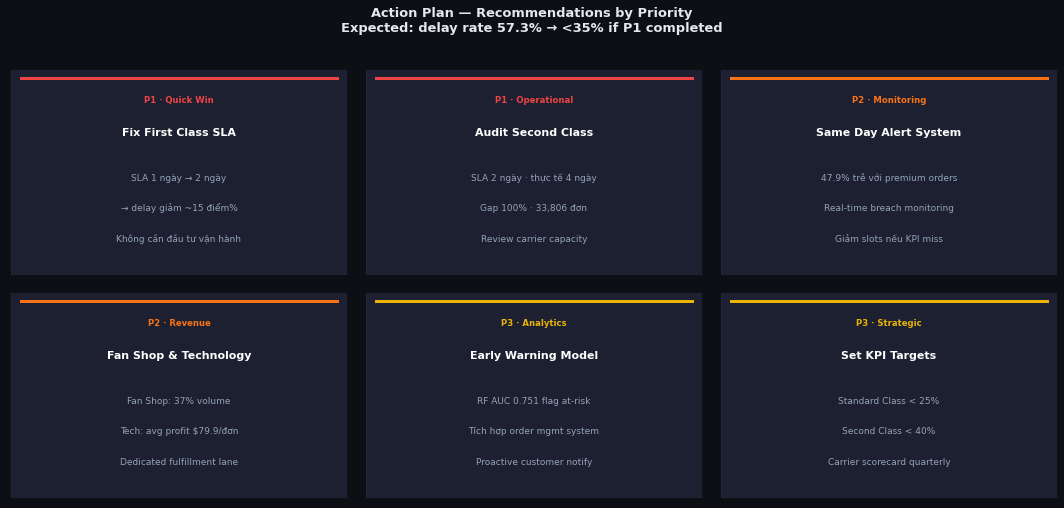

In [17]:
# ══════════════════════════════════════════════════════════════════════
# 8. RECOMMENDATION SUMMARY — Figure 7
# ══════════════════════════════════════════════════════════════════════
section("8. Recommendations Dashboard")

recs = [
    ("P1 · Quick Win", "Fix First Class SLA",
     "SLA 1 ngày → 2 ngày\n→ delay giảm ~15 điểm%\nKhông cần đầu tư vận hành", RED),
    ("P1 · Operational", "Audit Second Class",
     "SLA 2 ngày · thực tế 4 ngày\nGap 100% · 33,806 đơn\nReview carrier capacity", RED),
    ("P2 · Monitoring", "Same Day Alert System",
     "47.9% trễ với premium orders\nReal-time breach monitoring\nGiảm slots nếu KPI miss", ORANGE),
    ("P2 · Revenue", "Fan Shop & Technology",
     "Fan Shop: 37% volume\nTech: avg profit $79.9/đơn\nDedicated fulfillment lane", ORANGE),
    ("P3 · Analytics", "Early Warning Model",
     "RF AUC 0.751 flag at-risk\nTích hợp order mgmt system\nProactive customer notify", YELLOW),
    ("P3 · Strategic", "Set KPI Targets",
     "Standard Class < 25%\nSecond Class < 40%\nCarrier scorecard quarterly", YELLOW),
]

fig7, axes = plt.subplots(2, 3, figsize=(15, 7))
fig7.patch.set_facecolor(BG)
plt.suptitle(
    "Action Plan — Recommendations by Priority\n"
    "Expected: delay rate 57.3% → <35% if P1 completed",
    fontsize=13, fontweight='bold', color=TEXT, y=1.01
)

for ax, (priority, title, body, color) in zip(axes.flat, recs):
    ax.set_facecolor(SURF2)
    for sp in ax.spines.values(): sp.set_edgecolor(BORDER)
    ax.set_xticks([]); ax.set_yticks([])

    ax.axhline(y=0.96, xmin=0.03, xmax=0.97, color=color, linewidth=3)
    ax.text(0.5, 0.84, priority, ha='center', fontsize=8.5, color=color,
            fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.68, title, ha='center', fontsize=11, color='white',
            fontweight='bold', transform=ax.transAxes)
    ax.axhline(y=0.58, xmin=0.1, xmax=0.9, color=BORDER, linewidth=0.5)

    for i, line in enumerate(body.split('\n')):
        ax.text(0.5, 0.46 - i*0.15, line, ha='center', fontsize=9,
                color=LIGHT, transform=ax.transAxes)

plt.tight_layout(pad=1.5)
plt.show()
# plt.savefig('/mnt/user-data/outputs/fig7_recommendations.png', dpi=150,
#             bbox_inches='tight', facecolor=BG)
# plt.close()
# print("✓ fig7_recommendations.png")